# Homework 9: CNN for Fashion MNIST

**Advanced Machine Learning**

Classify **Fashion MNIST** images (10 apparel categories, 28×28 grayscale) with Keras CNNs.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
import optuna
from optuna.visualization import plot_optimization_history, plot_param_importances, plot_slice
from sklearn.metrics import classification_report, confusion_matrix

tf.random.set_seed(42)
np.random.seed(42)

CLASS_NAMES = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot",
]
NUM_CLASSES = 10


## 1. Load and prepare data


In [2]:
(X_train, y_train), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()

print("Train:", X_train.shape, y_train.shape)
print("Test:", X_test.shape, y_test.shape)

# Scale to [0, 1] and add channel dimension for Conv2D
X_train = (X_train.astype("float32") / 255.0)[..., np.newaxis]
X_test = (X_test.astype("float32") / 255.0)[..., np.newaxis]

print("Value range:", X_train.min(), "to", X_train.max())
print("Image shape:", X_train.shape[1:])


Train: (60000, 28, 28) (60000,)
Test: (10000, 28, 28) (10000,)
Value range: 0.0 to 1.0
Image shape: (28, 28, 1)


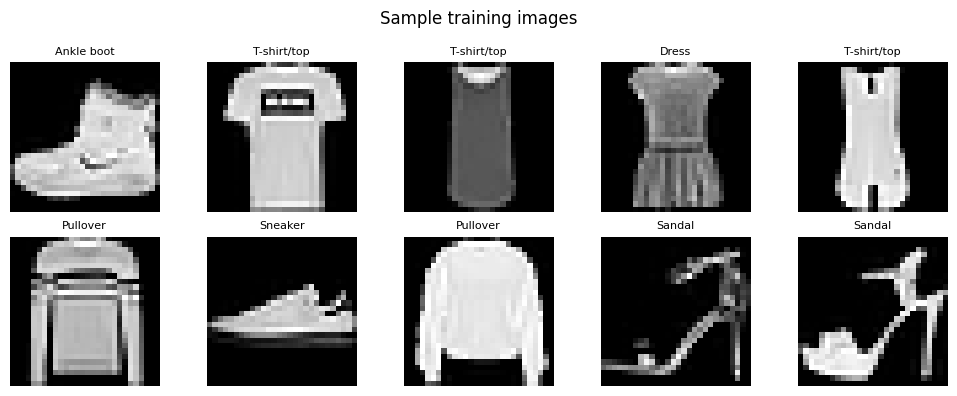

In [3]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[i].squeeze(), cmap="gray")
    ax.set_title(CLASS_NAMES[y_train[i]], fontsize=8)
    ax.axis("off")
plt.suptitle("Sample training images")
plt.tight_layout()
plt.show()


## 2. Baseline CNN

Two convolution blocks (32 → 64 filters), max pooling, dense head — same style as Week 8 `Inclass_05_21` cats/dogs CNN.


In [4]:
def build_baseline_cnn():
    return keras.Sequential([
        layers.Input(shape=(28, 28, 1)),
        layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(64, activation="relu"),
        layers.Dense(NUM_CLASSES, activation="softmax"),
    ])


keras.backend.clear_session()
tf.random.set_seed(42)

baseline_model = build_baseline_cnn()
baseline_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

baseline_history = baseline_model.fit(
    X_train, y_train,
    epochs=15,
    batch_size=128,
    validation_split=0.2,
    verbose=1,
)


Epoch 1/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 21s 54ms/step - accuracy: 0.8082 - loss: 0.5402 - val_accuracy: 0.8725 - val_loss: 0.3737
Epoch 2/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 20s 54ms/step - accuracy: 0.8786 - loss: 0.3431 - val_accuracy: 0.8831 - val_loss: 0.3279
Epoch 3/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 20s 54ms/step - accuracy: 0.8931 - loss: 0.2969 - val_accuracy: 0.8963 - val_loss: 0.2905
Epoch 4/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 21s 57ms/step - accuracy: 0.9043 - loss: 0.2647 - val_accuracy: 0.9008 - val_loss: 0.2698
Epoch 5/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 22s 58ms/step - accuracy: 0.9128 - loss: 0.2413 - val_accuracy: 0.9037 - val_loss: 0.2606
Epoch 6/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 22s 59ms/step - accuracy: 0.9201 - loss: 0.2216 - val_accuracy: 0.9076 - val_loss: 0.2549
Epoch 7/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 23s 61ms/step - accuracy: 0.9269 - loss: 0.2045 - val_accuracy: 0.9090 - val_loss: 0.2527
Epoch 8/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 21s 56ms/step - accuracy: 0.9326 - loss: 0.1883 - 

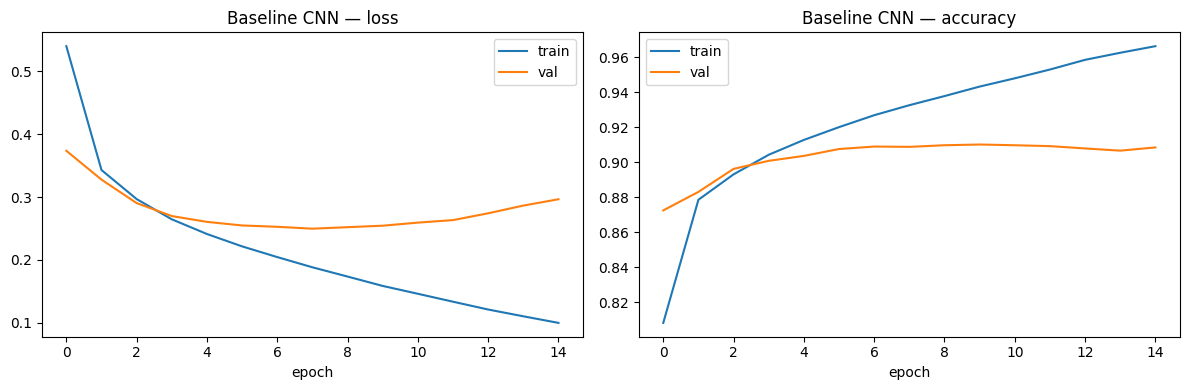

In [5]:
def plot_history(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history.history["loss"], label="train")
    axes[0].plot(history.history["val_loss"], label="val")
    axes[0].set_title(f"{title} — loss")
    axes[0].set_xlabel("epoch")
    axes[0].legend()
    axes[1].plot(history.history["accuracy"], label="train")
    axes[1].plot(history.history["val_accuracy"], label="val")
    axes[1].set_title(f"{title} — accuracy")
    axes[1].set_xlabel("epoch")
    axes[1].legend()
    plt.tight_layout()
    plt.show()


plot_history(baseline_history, "Baseline CNN")


In [6]:
baseline_test_loss, baseline_test_acc = baseline_model.evaluate(X_test, y_test, verbose=0)
print(f"Baseline test accuracy: {baseline_test_acc:.4f}")
print(f"Baseline test loss: {baseline_test_loss:.4f}")

y_pred_base = np.argmax(baseline_model.predict(X_test, verbose=0), axis=1)
print("\nClassification report (baseline):")
print(classification_report(y_test, y_pred_base, target_names=CLASS_NAMES))


Baseline test accuracy: 0.9062
Baseline test loss: 0.3130

Classification report (baseline):
              precision    recall  f1-score   support

 T-shirt/top       0.92      0.79      0.85      1000
     Trouser       1.00      0.97      0.99      1000
    Pullover       0.86      0.86      0.86      1000
       Dress       0.85      0.94      0.90      1000
        Coat       0.86      0.84      0.85      1000
      Sandal       0.98      0.98      0.98      1000
       Shirt       0.72      0.78      0.75      1000
     Sneaker       0.97      0.94      0.95      1000
         Bag       0.98      0.98      0.98      1000
  Ankle boot       0.94      0.98      0.96      1000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



## 3. Experiments — change one factor at a time

Fixed unless noted: Adam, `validation_split=0.2`, **15 epochs**, seed 42, same train/test split. Test accuracy is on the **held-out test set** (10,000 images).


### 3a. Factor: architecture (filter widths)


In [7]:
def build_cnn(filters=(32, 64), dense_units=64, dropout=0.0):
    reg_layers = []
    for f in filters:
        reg_layers += [
            layers.Conv2D(f, (3, 3), activation="relu", padding="same"),
            layers.MaxPooling2D((2, 2)),
        ]
        if dropout:
            reg_layers.append(layers.Dropout(dropout))
    return keras.Sequential(
        [layers.Input(shape=(28, 28, 1))]
        + reg_layers
        + [
            layers.Flatten(),
            layers.Dense(dense_units, activation="relu"),
            layers.Dense(NUM_CLASSES, activation="softmax"),
        ]
    )


def run_experiment(name, **build_kw):
    keras.backend.clear_session()
    tf.random.set_seed(42)
    model = build_cnn(**build_kw)
    model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    hist = model.fit(
        X_train, y_train, epochs=15, batch_size=128,
        validation_split=0.2, verbose=0,
    )
    loss, acc = model.evaluate(X_test, y_test, verbose=0)
    last = len(hist.history["loss"]) - 1
    return {
        "name": name,
        "test_acc": acc,
        "test_loss": loss,
        "train_acc": hist.history["accuracy"][last],
        "val_acc": hist.history["val_accuracy"][last],
        "history": hist,
    }


arch_results = []
arch_results.append(run_experiment("baseline [32,64]", filters=(32, 64)))
arch_results.append(run_experiment("wider [64,128]", filters=(64, 128)))
arch_results.append(run_experiment("narrow [16,32]", filters=(16, 32)))

pd.DataFrame([{k: v for k, v in r.items() if k != "history"} for r in arch_results])


,name,test_acc,test_loss,train_acc,val_acc
0,"baseline [32,64]",0.9093,0.290486,0.963375,0.914917
1,"wider [64,128]",0.9107,0.356087,0.972917,0.916333
2,"narrow [16,32]",0.9030,0.282110,0.940792,0.909833


**Takeaway:** Wider filters increase capacity; compare test accuracy above — wider nets can help if not overfitting.


### 3b. Factor: dropout (architecture fixed at [32, 64])


In [8]:
drop_results = []
for dr in [0.0, 0.25, 0.5]:
    drop_results.append(run_experiment(f"dropout {dr}", filters=(32, 64), dropout=dr))

pd.DataFrame([{k: v for k, v in r.items() if k != "history"} for r in drop_results])


,name,test_acc,test_loss,train_acc,val_acc
0,dropout 0.0,0.9096,0.292844,0.963458,0.912583
1,dropout 0.25,0.9128,0.248128,0.932938,0.917667
2,dropout 0.5,0.9113,0.245617,0.911542,0.917083


**Takeaway:** Moderate dropout can reduce overfitting when train accuracy runs ahead of validation.


### 3c. Factor: batch size (baseline architecture, no dropout)


In [9]:
batch_results = []

for bs in [32, 128, 256]:
    keras.backend.clear_session()
    tf.random.set_seed(42)
    model = build_cnn(filters=(32, 64))
    model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    hist = model.fit(
        X_train, y_train, epochs=15, batch_size=bs,
        validation_split=0.2, verbose=0,
    )
    loss, acc = model.evaluate(X_test, y_test, verbose=0)
    last = len(hist.history["loss"]) - 1
    batch_results.append({
        "name": f"batch {bs}",
        "batch_size": bs,
        "test_acc": acc,
        "train_acc": hist.history["accuracy"][last],
        "val_acc": hist.history["val_accuracy"][last],
    })

pd.DataFrame(batch_results)


,name,batch_size,test_acc,train_acc,val_acc
0,batch 32,32,0.9031,0.984375,0.911333
1,batch 128,128,0.9053,0.963500,0.907667
2,batch 256,256,0.9026,0.941896,0.910250


**Takeaway:** Batch size affects noise in gradient updates; very large batches can generalize slightly differently on small images.


## 4. Tuning with Optuna

Search over conv filter sizes, dense units, learning rate, batch size, and dropout. Objective = best **validation loss** with early stopping (pattern from `Inclass_05_14`).


In [ ]:
def objective(trial):
    tf.random.set_seed(42)
    f1 = trial.suggest_categorical("filters_1", [32, 64, 128])
    f2 = trial.suggest_categorical("filters_2", [64, 128, 256])
    dense_u = trial.suggest_int("dense_units", 32, 128, step=32)
    lr = trial.suggest_float("learning_rate", 1e-4, 1e-2, log=True)
    batch_size = trial.suggest_categorical("batch_size", [64, 128, 256])
    dropout = trial.suggest_float("dropout", 0.0, 0.5)

    model = build_cnn(filters=(f1, f2), dense_units=dense_u, dropout=dropout)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    early_stop = keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=5, restore_best_weights=True,
    )
    history = model.fit(
        X_train, y_train,
        epochs=30,
        batch_size=batch_size,
        validation_split=0.2,
        verbose=0,
        callbacks=[early_stop],
    )
    return min(history.history["val_loss"])


study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=25)

print("Best validation loss:", study.best_value)
print("Best params:", study.best_params)


[I 2026-05-28 11:43:48,184] A new study created in memory with name: no-name-cbdb90a8-3797-43b3-8c2c-a9fdd62befd4


In [ ]:
plot_optimization_history(study)
plot_param_importances(study)
plot_slice(study)


## 5. Final model and held-out test evaluation


In [ ]:
bp = study.best_params
keras.backend.clear_session()
tf.random.set_seed(42)

best_model = build_cnn(
    filters=(bp["filters_1"], bp["filters_2"]),
    dense_units=bp["dense_units"],
    dropout=bp["dropout"],
)
best_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=bp["learning_rate"]),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=5, restore_best_weights=True,
)

history_final = best_model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=bp["batch_size"],
    validation_split=0.2,
    verbose=1,
    callbacks=[early_stop],
)

plot_history(history_final, "Optuna final CNN")


In [ ]:
final_test_loss, final_test_acc = best_model.evaluate(X_test, y_test, verbose=0)
print(f"Final model test accuracy: {final_test_acc:.4f}")
print(f"Final model test loss: {final_test_loss:.4f}")

y_pred_final = np.argmax(best_model.predict(X_test, verbose=0), axis=1)
print("\nClassification report (final):")
print(classification_report(y_test, y_pred_final, target_names=CLASS_NAMES))

cm = confusion_matrix(y_test, y_pred_final)
plt.figure(figsize=(8, 6))
plt.imshow(cm, cmap="Blues")
plt.colorbar()
plt.xticks(range(10), CLASS_NAMES, rotation=45, ha="right")
plt.yticks(range(10), CLASS_NAMES)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion matrix — final model")
plt.tight_layout()
plt.show()


In [ ]:
# Summary table
summary = pd.DataFrame([
    {"Model": "Baseline CNN", "test_acc": baseline_test_acc},
    {"Model": "Best arch (manual)", "test_acc": max(r["test_acc"] for r in arch_results)},
    {"Model": "Best dropout (manual)", "test_acc": max(r["test_acc"] for r in drop_results)},
    {"Model": "Optuna final", "test_acc": final_test_acc},
])
summary


## 6. Conclusions

*Update the numbers below from your run outputs if they differ slightly.*

**Data:** 60,000 training / 10,000 test images; pixel values scaled to [0, 1]; shape `(28, 28, 1)` for Conv2D.

**Baseline:** Two-block CNN; check train vs val curves for overfitting (train accuracy rising faster than val).

**One-factor experiments:**
- **Architecture:** Compare `arch_results` — wider vs narrow filter stacks.
- **Dropout:** Compare `drop_results` — whether val/test improve when train–val gap is large.
- **Batch size:** Compare `batch_results` — stability vs speed tradeoff.

**Optuna:** Best validation loss and params printed in §4; final model retrained with early stopping and evaluated once on **X_test**.

**Overfitting:** If training accuracy ≈ 0.95+ while validation stalls lower, use dropout, fewer filters, or early stopping (as in the final model).

**Class confusion:** Shirt vs T-shirt/top and Coat vs Pullover are commonly confused — see confusion matrix.

**Best model:** The Optuna-tuned CNN should match or beat the baseline on **test accuracy**; cite your `summary` table.


## 7. Personal workflow (future reference)

1. **Load & inspect** — `fashion_mnist.load_data()`, plot samples, confirm shape and class balance.
2. **Preprocess for CNNs** — scale to [0, 1], add channel axis; keep official test set untouched.
3. **Baseline CNN** — small Conv2D stack + pool + dense; plot train/val loss and accuracy.
4. **Diagnose** — train–val gap → overfitting; both low → underfitting.
5. **One factor at a time** — architecture, then regularization, then batch size/learning rate; fix seed and epochs.
6. **Optuna** — tune on validation loss with early stopping; retrain best config once.
7. **Test once** — classification report + confusion matrix on held-out test.
8. **Pitfalls** — evaluating on test during tuning; forgetting `[..., np.newaxis]`; too many epochs without early stopping on small images.
